## Imports & Setup

In [1]:
import torch
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Import from your custom modules
import config
from utils.dataloader import get_dataloaders
from utils.engine import train_model
from models.inceptionv3 import get_inception_v3

print(f"Using Device: {config.DEVICE}")
# InceptionV3 requires 299x299 — different from the other models
print(f"Batch Size: {config.BATCH_SIZE} | Image Size: {config.INCEPTION_IMG_SIZE}")

Using Device: cuda
Batch Size: 32 | Image Size: 299


## Load the Dataset

In [2]:
# Pass INCEPTION_IMG_SIZE so images are resized to 299x299
# All other notebooks call get_dataloaders() with no argument — this does not affect them
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    img_size=config.INCEPTION_IMG_SIZE
)

# Verify a batch shape — should show torch.Size([32, 3, 299, 299])
images, labels = next(iter(train_loader))
print(f"\nBatch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

Image size   : 299×299
Train images : 1000
Val images   : 36
Test images  : 38
Classes      : ['Angry', 'Other', 'Sad', 'happy']

Batch image shape: torch.Size([32, 3, 299, 299])
Batch label shape: torch.Size([32])


## Initialize InceptionV3

In [3]:
# Initialize the model and push to GPU
# aux_logits=True: auxiliary classifier active during training (disabled automatically at eval)
model = get_inception_v3(
    num_classes=config.NUM_CLASSES,
    aux_logits=True
).to(config.DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"InceptionV3 Total Trainable Parameters: {total_params:,}")

InceptionV3 Total Trainable Parameters: 24,354,536


## Execute Training Loop

In [4]:
# Run the training engine
# engine.py handles the (main_logits, aux_logits) tuple automatically
trained_model, best_accuracy, all_preds, all_labels = train_model(
    model=model,
    model_name="InceptionV3_FromScratch",
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=class_names,
    epochs=config.EPOCHS,
    patience=7
)

print(f"\nTraining Complete! Best Validation Accuracy: {best_accuracy:.4f}")


  Training : InceptionV3_FromScratch  |  device: cuda
Epoch [ 1/30]  Train Loss: 2.0053  Train Acc: 0.2720  |  Val Loss: 1.3742  Val Acc: 0.3056
  Model saved with Val Acc: 0.3056
Epoch [ 2/30]  Train Loss: 1.9490  Train Acc: 0.2740  |  Val Loss: 1.3770  Val Acc: 0.3056
  EarlyStopping: no improvement for 1/7 epochs
Epoch [ 3/30]  Train Loss: 1.9267  Train Acc: 0.3170  |  Val Loss: 1.8325  Val Acc: 0.2222
  EarlyStopping: no improvement for 2/7 epochs
Epoch [ 4/30]  Train Loss: 1.9367  Train Acc: 0.2940  |  Val Loss: 1.9754  Val Acc: 0.3056
  EarlyStopping: no improvement for 3/7 epochs
Epoch [ 5/30]  Train Loss: 1.9607  Train Acc: 0.2730  |  Val Loss: 1.4011  Val Acc: 0.2222
  EarlyStopping: no improvement for 4/7 epochs
Epoch [ 6/30]  Train Loss: 1.9320  Train Acc: 0.2780  |  Val Loss: 1.3666  Val Acc: 0.3056
Epoch [ 7/30]  Train Loss: 1.9063  Train Acc: 0.3020  |  Val Loss: 1.3445  Val Acc: 0.3889
  Model saved with Val Acc: 0.3889
Epoch [ 8/30]  Train Loss: 1.8820  Train Acc: 0.33

## Visualize Training History

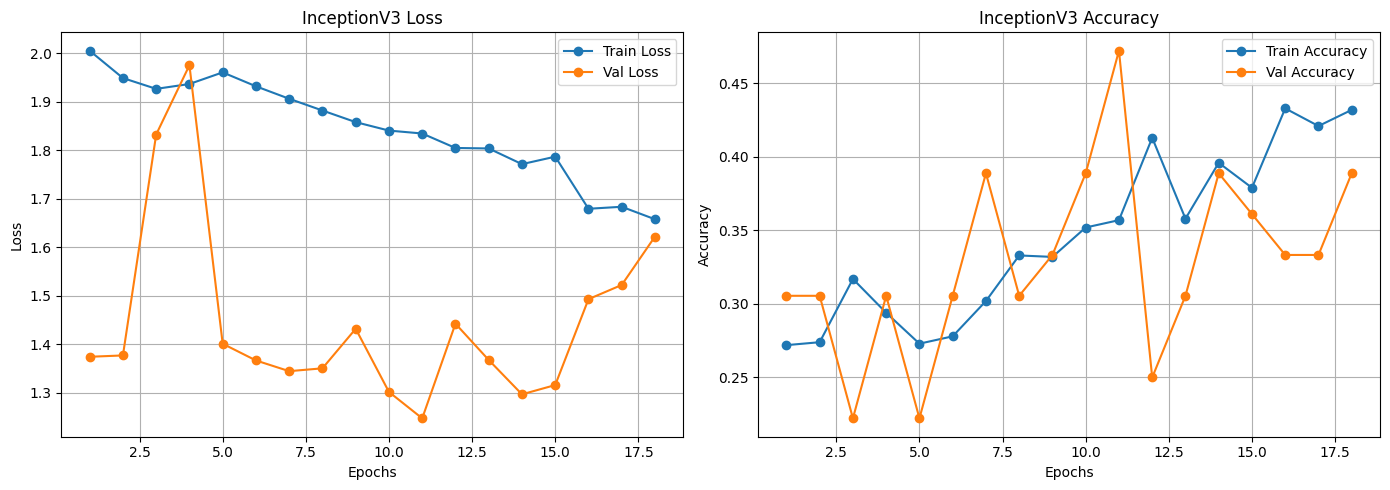

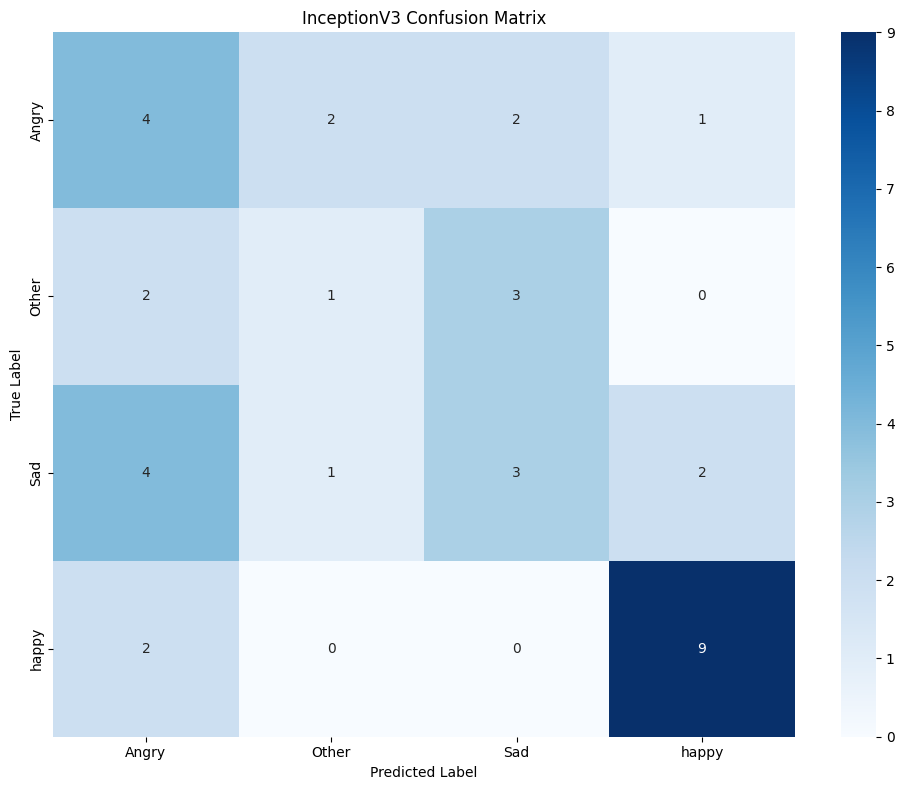

In [5]:
# Load the saved history
history_path = os.path.join(config.CHECKPOINT_DIR, "InceptionV3_FromScratch_history.pt")

if os.path.exists(history_path):
    history = torch.load(history_path)

    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='o')
    plt.title('InceptionV3 Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs_range, history['val_acc'],   label='Val Accuracy',   marker='o')
    plt.title('InceptionV3 Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title('InceptionV3 Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
else:
    print("History file not found. Run the training cell first.")